In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter, YearLocator

from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Dense, InputLayer, LSTM, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import keras
import re
import math
from tensorflow.keras.utils import Sequence

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

2026-01-20 14:47:05.922956: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768920426.102000      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768920426.152712      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768920426.563577      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768920426.563627      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768920426.563630      24 computation_placer.cc:177] computation placer alr

/kaggle/input/web-traffic-time-series-forecasting/sample_submission_2.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/sample_submission_1.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/train_2.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/key_1.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/key_2.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/train_1.csv.zip


In [2]:
path1 = "/kaggle/input/web-traffic-time-series-forecasting/train_2.csv.zip"
path2 = "/kaggle/input/web-traffic-time-series-forecasting/key_1.csv.zip"
path3 = "/kaggle/input/web-traffic-time-series-forecasting/key_2.csv.zip"
path4 = "/kaggle/input/web-traffic-time-series-forecasting/train_1.csv.zip"

key1 = pd.read_csv(path2)
key2 = pd.read_csv(path3) 

train2 = pd.read_csv(path1)
train1= pd.read_csv(path4)

test = pd.read_csv('/kaggle/input/web-traffic-time-series-forecasting/sample_submission_1.csv.zip')

In [3]:
print(f"train2_shape: {train2.shape}")

train2_shape: (145063, 804)


In [4]:
train2.head(10)

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2017-09-01,2017-09-02,2017-09-03,2017-09-04,2017-09-05,2017-09-06,2017-09-07,2017-09-08,2017-09-09,2017-09-10
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,19.0,33.0,33.0,18.0,16.0,27.0,29.0,23.0,54.0,38.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,32.0,30.0,11.0,19.0,54.0,25.0,26.0,23.0,13.0,81.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,6.0,6.0,7.0,2.0,4.0,7.0,3.0,4.0,7.0,6.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,7.0,19.0,19.0,9.0,6.0,16.0,19.0,30.0,38.0,4.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.0,16.0,19.0,9.0,20.0,23.0,28.0,14.0,8.0,7.0
5,5566_zh.wikipedia.org_all-access_spider,12.0,7.0,4.0,5.0,20.0,8.0,5.0,17.0,24.0,...,13.0,13.0,45.0,4.0,13.0,20.0,18.0,17.0,14.0,11.0
6,91Days_zh.wikipedia.org_all-access_spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0,8.0,5.0,7.0,8.0,10.0,8.0,5.0,3.0,5.0
7,A'N'D_zh.wikipedia.org_all-access_spider,118.0,26.0,30.0,24.0,29.0,127.0,53.0,37.0,20.0,...,74.0,39.0,11.0,55.0,71.0,44.0,25.0,39.0,25.0,50.0
8,AKB48_zh.wikipedia.org_all-access_spider,5.0,23.0,14.0,12.0,9.0,9.0,35.0,15.0,14.0,...,53.0,107.0,63.0,42.0,24.0,44.0,33.0,52.0,21.0,48.0
9,ASCII_zh.wikipedia.org_all-access_spider,6.0,3.0,5.0,12.0,6.0,5.0,4.0,13.0,9.0,...,20.0,16.0,22.0,19.0,21.0,32.0,34.0,29.0,23.0,25.0


In [5]:
WINDOW_SIZE = 120
horizon = 64

In [6]:
def get_language(page_name):
    res = re.search('[a-z][a-z].wikipedia.org', page_name)
    if res:
        return res.group(0)[0:2]
    return 'na'  

print("Extraction de la langue...")
train2['lang'] = train2['Page'].map(get_language)

lang_codes, lang_unique = pd.factorize(train2['lang'])
train2['lang_norm'] = lang_codes / lang_codes.max() # Entre 0 et 1

print("Langues extraites :", lang_unique)

Extraction de la langue...
Langues extraites : Index(['zh', 'fr', 'en', 'na', 'ru', 'de', 'ja', 'es'], dtype='object')


In [7]:
dates = pd.to_datetime(train2.columns[1:-2]) # -2 car on a ajouté 'lang' et 'lang_norm' à la fin
dow_global = (dates.dayofweek / 6)
month_global = (dates.month / 12)
we_global = (dates.dayofweek > 4).astype(int)

 
def create_dataset_features(series, rolling, lang_val, dow, m, we):
    X, y = [], []
    max_idx = len(series) - WINDOW_SIZE - horizon + 1
    
    
    lang_vec = np.full(WINDOW_SIZE, lang_val)
    
    for i in range(0, max_idx, 10):
         
        window_traffic = series[i : i + WINDOW_SIZE]
        window_rolling = rolling[i : i + WINDOW_SIZE]
        
        
        w_dow = dow[i : i + WINDOW_SIZE]
        w_m = m[i : i + WINDOW_SIZE]
        w_we = we[i : i + WINDOW_SIZE]
        
        
        sample = np.stack([
            window_traffic, 
            window_rolling,  
            lang_vec,       
            w_dow, w_m, w_we
        ], axis=1)
        
        target = series[i + WINDOW_SIZE : i + WINDOW_SIZE + horizon]
        X.append(sample)
        y.append(target)
    return X, y

X_all, y_all = [], []
n_pages = min(10000, len(train2))  

print(f"Traitement avec features avancées pour {n_pages} pages...")

 
traffic_data = train2.iloc[:, 1:-2] 

for i in range(n_pages):
    
    ts = pd.to_numeric(traffic_data.iloc[i, :], errors='coerce').fillna(0)
    
     
    ts_log = np.log1p(ts.values)
    
     
    ts_rolling = pd.Series(ts_log).rolling(window=7, min_periods=1).mean().fillna(0).values
    
    
    lang_val = train2.iloc[i]['lang_norm']
    
    
    X_p, y_p = create_dataset_features(ts_log, ts_rolling, lang_val, dow_global, month_global, we_global)
    X_all.extend(X_p)
    y_all.extend(y_p)

train_input = np.array(X_all)
train_output = np.array(y_all)

print(f"Nouvelle Shape Input: {train_input.shape}") 

Traitement avec features avancées pour 10000 pages...
Nouvelle Shape Input: (620000, 120, 6)


In [8]:
class ValGenerator(Sequence):
    def __init__(self, data, rolling, lang, dow, month, we, window, horizon, batch_size=256):
        self.data = data
        self.rolling = rolling
        self.lang = lang
        self.dow = dow
        self.month = month
        self.we = we
        self.window = window
        self.horizon = horizon
        self.batch_size = batch_size
        self.n_pages = data.shape[0]
        self.n_days = data.shape[1]
        
        self.start_t = self.n_days - window - horizon

    def __len__(self):
        return int(np.ceil(self.n_pages / self.batch_size))

    def __getitem__(self, idx):
        start_idx = idx * self.batch_size
        end_idx = min((idx + 1) * self.batch_size, self.n_pages)
        page_indices = np.arange(start_idx, end_idx)
        
        batch_x = []
        batch_y = []
        
        for i in page_indices:
            start_t = self.start_t
            end_t = start_t + self.window
            
            seq_traffic = self.data[i, start_t:end_t]
            seq_rolling = self.rolling[i, start_t:end_t]
            seq_lang = np.full(self.window, self.lang[i])
            seq_dow = self.dow[start_t:end_t]
            seq_month = self.month[start_t:end_t]
            seq_we = self.we[start_t:end_t]
            
            x_sample = np.stack([
                seq_traffic,
                seq_rolling,
                seq_lang,
                seq_dow,
                seq_month,
                seq_we
            ], axis=1)
            
            y_sample = self.data[i, end_t : end_t + self.horizon]
            
            batch_x.append(x_sample)
            batch_y.append(y_sample)
            
        return np.array(batch_x), np.array(batch_y)

In [9]:
traffic_data = train2.iloc[:, 1:-2]
data_matrix = np.log1p(traffic_data.fillna(0))
rolling_matrix = pd.DataFrame(data_matrix).rolling(window=7, min_periods=1, axis=1).mean().fillna(0)
lang_codes = train2['lang_norm']

class TrafficGenerator(Sequence):
    def __init__(self, data, rolling, lang, dow, month, we, window, horizon, batch_size=256):
        self.data = np.array(data)
        self.rolling = np.array(rolling)
        self.lang = np.array(lang)
        self.dow = np.array(dow)
        self.month = np.array(month)
        self.we = np.array(we)
        
        self.window = window
        self.horizon = horizon
        self.batch_size = batch_size
        self.n_pages = self.data.shape[0]
        self.n_days = self.data.shape[1]
        self.valid_days = self.n_days - window - horizon
        
    def __len__(self):
        return int(np.ceil(self.n_pages / self.batch_size)) * 5

    def __getitem__(self, idx):
        batch_x = []
        batch_y = []
        
        page_indices = np.random.randint(0, self.n_pages, size=self.batch_size)
        
        for i in page_indices:
            start_t = np.random.randint(0, self.valid_days)
            end_t = start_t + self.window
            
            # Maintenant ça marche car c'est du numpy en interne
            seq_traffic = self.data[i, start_t:end_t]
            seq_rolling = self.rolling[i, start_t:end_t]
            seq_lang = np.full(self.window, self.lang[i])
            seq_dow = self.dow[start_t:end_t]
            seq_month = self.month[start_t:end_t]
            seq_we = self.we[start_t:end_t]
            
            x_sample = np.stack([
                seq_traffic, seq_rolling, seq_lang,
                seq_dow, seq_month, seq_we
            ], axis=1)
            
            y_sample = self.data[i, end_t : end_t + self.horizon]
            
            batch_x.append(x_sample)
            batch_y.append(y_sample)
            
        return np.array(batch_x), np.array(batch_y)

class ValGenerator(Sequence):
    def __init__(self, data, rolling, lang, dow, month, we, window, horizon, batch_size=256):
        # CORRECTION ICI AUSSI : Conversion interne
        self.data = np.array(data)
        self.rolling = np.array(rolling)
        self.lang = np.array(lang)
        self.dow = np.array(dow)
        self.month = np.array(month)
        self.we = np.array(we)
        
        self.window = window
        self.horizon = horizon
        self.batch_size = batch_size
        self.n_pages = self.data.shape[0]
        self.n_days = self.data.shape[1]
        self.start_t = self.n_days - window - horizon

    def __len__(self):
        return int(np.ceil(self.n_pages / self.batch_size))

    def __getitem__(self, idx):
        start_idx = idx * self.batch_size
        end_idx = min((idx + 1) * self.batch_size, self.n_pages)
        page_indices = np.arange(start_idx, end_idx)
        
        batch_x = []
        batch_y = []
        
        for i in page_indices:
            start_t = self.start_t
            end_t = start_t + self.window
            
            seq_traffic = self.data[i, start_t:end_t]
            seq_rolling = self.rolling[i, start_t:end_t]
            seq_lang = np.full(self.window, self.lang[i])
            seq_dow = self.dow[start_t:end_t]
            seq_month = self.month[start_t:end_t]
            seq_we = self.we[start_t:end_t]
            
            x_sample = np.stack([
                seq_traffic, seq_rolling, seq_lang,
                seq_dow, seq_month, seq_we
            ], axis=1)
            
            y_sample = self.data[i, end_t : end_t + self.horizon]
            batch_x.append(x_sample)
            batch_y.append(y_sample)
            
        return np.array(batch_x), np.array(batch_y)

train_gen = TrafficGenerator(
    data_matrix, 
    rolling_matrix, 
    lang_codes, 
    dow_global, 
    month_global, 
    we_global, 
    WINDOW_SIZE, 
    horizon, 
    batch_size=256
)

val_gen = ValGenerator(
    data_matrix, 
    rolling_matrix, 
    lang_codes, 
    dow_global, 
    month_global, 
    we_global, 
    WINDOW_SIZE, 
    horizon, 
    batch_size=256
)

model = Sequential()
model.add(InputLayer((WINDOW_SIZE, 6)))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dense(horizon, activation='linear'))

model.compile(loss='huber', optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
check_point = ModelCheckpoint('model.keras', save_best_only=True, monitor='val_loss')

model.fit(train_gen, validation_data=val_gen, epochs=30, callbacks=[check_point, early_stop])

/tmp/ipykernel_24/417904920.py:3: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  rolling_matrix = pd.DataFrame(data_matrix).rolling(window=7, min_periods=1, axis=1).mean().fillna(0)
I0000 00:00:1768920543.615453      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768920543.619290      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1768920547.637044      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


2835/2835 ━━━━━━━━━━━━━━━━━━━━ 68s 23ms/step - loss: 0.4038 - root_mean_squared_error: 1.1731 - val_loss: 0.2200 - val_root_mean_squared_error: 0.7184
Epoch 2/30
2835/2835 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - loss: 0.2005 - root_mean_squared_error: 0.7705 - val_loss: 0.1772 - val_root_mean_squared_error: 0.6489
Epoch 3/30
2835/2835 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - loss: 0.1959 - root_mean_squared_error: 0.7643 - val_loss: 0.1761 - val_root_mean_squared_error: 0.6475
Epoch 4/30
2835/2835 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - loss: 0.1902 - root_mean_squared_error: 0.7547 - val_loss: 0.1577 - val_root_mean_squared_error: 0.6129
Epoch 5/30
2835/2835 ━━━━━━━━━━━━━━━━━━━━ 64s 23ms/step - loss: 0.1877 - root_mean_squared_error: 0.7503 - val_loss: 0.1604 - val_root_mean_squared_error: 0.6176
Epoch 6/30
2835/2835 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - loss: 0.1861 - root_mean_squared_error: 0.7486 - val_loss: 0.1589 - val_root_mean_squared_error: 0.6154
Epoch 7/30
2835/2835 ━━━━━━━━━━━━━━━━━━

In [10]:
model = keras.models.load_model('model.keras')

Ici il faut optimier l'allocation de mémoire car le code en demande + que ce qu'il y'a de prévu 

In [11]:
import gc
extra_days = 7
required_days = WINDOW_SIZE + extra_days

traffic_cols = train2.columns[1:-2][-required_days:]
x_raw_extended = train2[traffic_cols].fillna(0).values.astype(np.float32)  # float32 au lieu de float64

gc.collect()
 
x_log_extended = np.log1p(x_raw_extended)
del x_raw_extended
gc.collect()

from scipy.ndimage import uniform_filter1d

def fast_rolling_mean(arr, window=7):
    """Rolling mean avec scipy - beaucoup plus rapide et moins de RAM"""
    result = uniform_filter1d(arr.astype(np.float32), size=window, axis=1, mode='nearest')
    return result[:, -WINDOW_SIZE:]

x_rolling = fast_rolling_mean(x_log_extended, window=7)
x_log = x_log_extended[:, -WINDOW_SIZE:].astype(np.float32)

del x_log_extended
gc.collect()


n_samples = x_log.shape[0]

lang_vals = train2['lang_norm'].values.astype(np.float32)
lang_pred = np.broadcast_to(lang_vals[:, np.newaxis], (n_samples, WINDOW_SIZE)).astype(np.float32)


dow_pred = np.broadcast_to(dow_global[-WINDOW_SIZE:].astype(np.float32), (n_samples, WINDOW_SIZE))
month_pred = np.broadcast_to(month_global[-WINDOW_SIZE:].astype(np.float32), (n_samples, WINDOW_SIZE))
we_pred = np.broadcast_to(we_global[-WINDOW_SIZE:].astype(np.float32), (n_samples, WINDOW_SIZE))


print(f"Préparation pour prédiction : {n_samples} séries")

 
CHUNK_SIZE = 10000  # Ajuster selon ta RAM disponible
predictions_list = []

for start_idx in range(0, n_samples, CHUNK_SIZE):
    end_idx = min(start_idx + CHUNK_SIZE, n_samples)
    
     
    x_chunk = np.stack([
        x_log[start_idx:end_idx], 
        x_rolling[start_idx:end_idx], 
        np.ascontiguousarray(lang_pred[start_idx:end_idx]),
        np.ascontiguousarray(dow_pred[start_idx:end_idx]),
        np.ascontiguousarray(month_pred[start_idx:end_idx]),
        np.ascontiguousarray(we_pred[start_idx:end_idx])
    ], axis=2).astype(np.float32)
    
   
    preds_chunk = model.predict(x_chunk, batch_size=512, verbose=0)
    predictions_list.append(np.expm1(preds_chunk))
    
    del x_chunk
    gc.collect()
    
    if (start_idx // CHUNK_SIZE) % 5 == 0:
        print(f"  Progression: {end_idx}/{n_samples}")

# Assembler les prédictions
predictions = np.vstack(predictions_list).astype(np.float32)
predictions = np.clip(predictions, 0, None)

del predictions_list, x_log, x_rolling, lang_pred, dow_pred, month_pred, we_pred
gc.collect()

print(f"Prédictions terminées : {predictions.shape}")


key2['date'] = key2['Page'].str.extract(r'_(\d{4}-\d{2}-\d{2})$')
key2['page_name'] = key2['Page'].str.replace(r'_\d{4}-\d{2}-\d{2}$', '', regex=True)

dates_attendues = sorted(key2['date'].unique())
print(f"Dates attendues : {dates_attendues[0]} à {dates_attendues[-1]}")

if len(dates_attendues) != horizon:
    print(f"Attention : horizon={horizon} mais {len(dates_attendues)} jours attendus")
    predictions = predictions[:, :len(dates_attendues)]
 
pages = train2['Page'].values

 
submission_rows = []
for i, page in enumerate(pages):
    for j, date in enumerate(dates_attendues):
        submission_rows.append({
            'Page': f"{page}_{date}",
            'Visits': int(max(0, round(predictions[i, j])))
        })
    
     
    if i % 10000 == 0 and i > 0:
        gc.collect()
        print(f"  Construction submission: {i}/{len(pages)}")

del predictions
gc.collect()

submission_df = pd.DataFrame(submission_rows)
del submission_rows
gc.collect()

# Merge final
final_submission = key2[['Id', 'Page']].merge(submission_df, on='Page', how='left')
del submission_df
gc.collect()

final_submission['Visits'] = final_submission['Visits'].fillna(0).astype(int)
final_submission[['Id', 'Visits']].to_csv('submission_lstm_fixed.csv', index=False)

print(f"Soumission créée : {final_submission.shape[0]} lignes")
print(final_submission.head())


Préparation pour prédiction : 145063 séries
  Progression: 10000/145063
  Progression: 60000/145063
  Progression: 110000/145063
Prédictions terminées : (145063, 64)
Dates attendues : 2017-09-13 à 2017-11-13
Attention : horizon=64 mais 62 jours attendus
  Construction submission: 10000/145063
  Construction submission: 20000/145063
  Construction submission: 30000/145063
  Construction submission: 40000/145063
  Construction submission: 50000/145063
  Construction submission: 60000/145063
  Construction submission: 70000/145063
  Construction submission: 80000/145063
  Construction submission: 90000/145063
  Construction submission: 100000/145063
  Construction submission: 110000/145063
  Construction submission: 120000/145063
  Construction submission: 130000/145063
  Construction submission: 140000/145063
Soumission créée : 8993906 lignes
             Id                                               Page  Visits
0  0b293039387a  007_スペクター_ja.wikipedia.org_all-access_all-agen...     4

ValueError: x and y must have same first dimension, but have shapes (64,) and (60,)

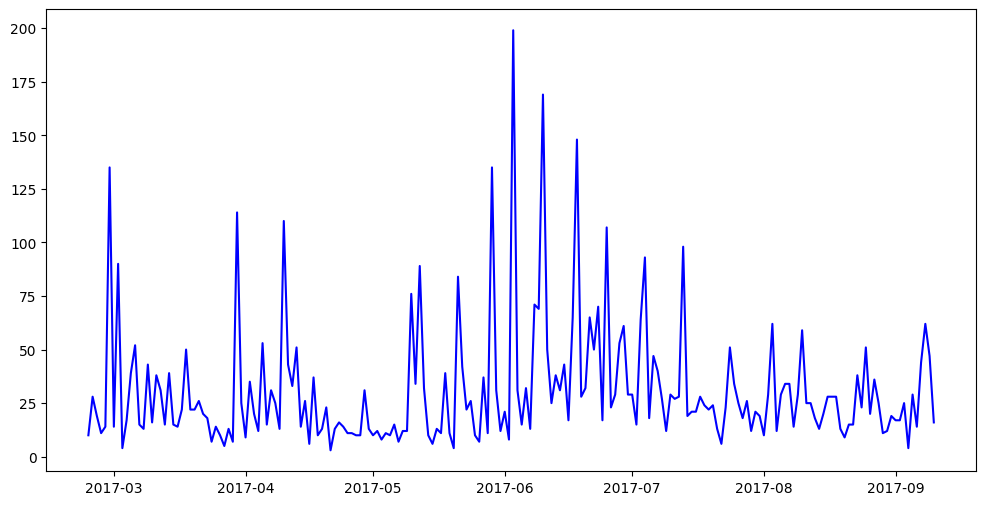

In [12]:
u = 10  
jours_a_afficher = 60


ts_full = pd.to_numeric(train2.iloc[u, 1:-2], errors='coerce').fillna(0)

# 2. Préparation des 120 derniers jours pour l'input
ts_input = ts_full.values[-WINDOW_SIZE:]
ts_log = np.log1p(ts_input)

# --- Feature 1 : Rolling Mean ---
# On calcule la moyenne mobile sur cette fenêtre
ts_rolling = pd.Series(ts_log).rolling(window=7, min_periods=1).mean().fillna(0).values

# --- Feature 2 : Langue ---
# On récupère la langue de la page u
lang_val = train2.iloc[u]['lang_norm']
lang_vec = np.full(WINDOW_SIZE, lang_val)

# --- Features Temporelles ---
dow_g = dow_global[-WINDOW_SIZE:]
month_g = month_global[-WINDOW_SIZE:]
we_g = we_global[-WINDOW_SIZE:]

# --- Stack (6 Features) ---
input_seq = np.stack([
    ts_log, 
    ts_rolling, 
    lang_vec, 
    dow_g, 
    month_g, 
    we_g
], axis=1).reshape((1, WINDOW_SIZE, 6)) # Shape (1, 120, 6)

# 3. Prédiction
prediction_log = model.predict(input_seq, verbose=0)[0]
prediction = np.expm1(prediction_log).clip(0.0)

# 4. Graphique
last_date = pd.to_datetime(traffic_data.columns[-1])
dates_hist = pd.to_datetime(traffic_data.columns)
dates_futures = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon)

plt.figure(figsize=(12, 6))
# On affiche les 200 derniers jours de l'historique
plt.plot(dates_hist[-200:], ts_full.values[-200:], label="Historique", color="blue")
plt.plot(dates_futures, prediction[:jours_a_afficher], label="Prédictions (LSTM)", color="red", linestyle="--")

plt.title(f"Page : {train2.iloc[u, 0]} (Langue: {train2.iloc[u]['lang']})")
plt.xlabel("Date")
plt.ylabel("Visites")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()